<a href="https://colab.research.google.com/github/ramsaher/DEVF_Master_Ciencias_de_Datos/blob/main/Leccion_8_Proyecto_Introducci%C3%B3n_al_An%C3%A1lisis_Estad%C3%ADstico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

# **Dataset: Cafe Sales — Dirty Data for Cleaning Training**

¿Qué vamos a hacer en este proyecto?

Imaginemos que nos contratan como analista de datos en una cadena de cafeterías. Nos entregan una base de datos real (y muy sucia) con 10,000 transacciones de venta. La misión es:

- Entender qué contiene el dataset y de dónde viene
- Limpiarlo — corregir errores, nulos, inconsistencias
- Explorarlo — estadísticas, distribuciones, correlaciones
- Visualizarlo — contar una historia con gráficas que cualquier persona entienda
- Bonus: predecir ventas con regresión lineal simple

#   SECCIÓN 1: Instalación e Importación de Librerías

Antes de hacer cualquier cosa, necesitamos traer a nuestro entorno las **herramientas** (librerías) que vamos a usar. Pensemos en esto como abrir la caja de herramientas antes de empezar a trabajar.

In [142]:
# Importar las librerías que usaremos

import pandas as pd  # Para manipular datos (como Excel pero más potente)
import numpy as np   # Para operaciones matemáticas
import matplotlib.pyplot as plt  # Para gráficos básicos
import seaborn as sns  # Para gráficos bonitos y fáciles
import warnings
warnings.filterwarnings('ignore')  # Ignoramos mensajes de advertencia

# Configuración para que los gráficos

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Librerías cargadas correctamente")

 Librerías cargadas correctamente


#   SECCIÓN 2: Recopilación de Datos
Cargar el dataset y entender su estructura

# ¿De dónde viene este dataset?

- **Fuente:** Kaggle — Plataforma pública de datasets para ciencia de datos
- **Nombre:** *Cafe Sales - Dirty Data for Cleaning Training*
  (https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training)
- **Contexto:** Registro de transacciones de una cafetería durante el año 2023
- **Propósito original del dataset:** Practicar limpieza de datos (contiene errores intencionales)

### ¿Qué columnas tiene?

| Columna | Significado |
|---|---|
| `Transaction ID` | Código único de cada venta |
| `Item` | Producto vendido (café, pastel, etc.) |
| `Quantity` | Cantidad de unidades vendidas |
| `Price Per Unit` | Precio unitario del producto |
| `Total Spent` | Total pagado (Quantity × Price Per Unit) |
| `Payment Method` | Forma de pago (efectivo, tarjeta, etc.) |
| `Location` | Dónde se realizó la compra (local o para llevar) |
| `Transaction Date` | Fecha de la transacción |

In [143]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [144]:
# Cargamos el dataset desde Drive

ruta_colab = '/content/MyDrive/'
df = pd.read_csv('/content/drive/MyDrive/dirty_cafe_sales.csv')
print("\n Cargando dataset de ventas de café...")
print("Dataset cargado exitosamente")
print(f" El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas")
#  Ver las primeras filas
print("\n Primeras 5 filas del dataset:")
df.head(10)



 Cargando dataset de ventas de café...
Dataset cargado exitosamente
 El dataset tiene 10000 filas y 8 columnas

 Primeras 5 filas del dataset:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


**Explicación: df.info() nos muestra:**
 - Nombres de las columnas
 - Cuántos valores NO nulos tiene cada columna
 - Tipo de dato de cada columna (object = texto, float64 = número decimal, int64 = número entero)

In [145]:
# Ver información general del dataset

print("\n INFORMACIÓN GENERAL DEL DATASET:")
print("-" * 40)
df.info()


 INFORMACIÓN GENERAL DEL DATASET:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


 **Explicación: df.describe() calcula automáticamente**
 - count: cuántos valores hay (si es menor al total, hay valores nulos)
 - mean: promedio
 - std: desviación estándar (qué tan dispersos están los datos)
 - min: valor mínimo
 - 25%, 50%, 75%: percentiles (el 50% es la mediana)
 - max: valor máximo

In [146]:
# Ver estadísticas básicas de las columnas numéricas

print("\n ESTADÍSTICAS BÁSICAS (COLUMNAS NUMÉRICAS):")
print("-" * 40)
df.describe()


 ESTADÍSTICAS BÁSICAS (COLUMNAS NUMÉRICAS):
----------------------------------------


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


# Diagnóstico del dataset — ¿Qué tan sucio está?

In [147]:
# Contamos los  valores nulos (NaN) por columna
# Un valor nulo es una celda vacía — falta información

nulos = df.isnull().sum()

# Calculamos el porcentaje de nulos respecto al total de filas

pct_nulos = (nulos / len(df) * 100).round(2)

# Creamos una tabla resumen de diagnóstico

diagnostico = pd.DataFrame({
    'Tipo de dato': df.dtypes,
    'Valores nulos': nulos,
    '% Nulos': pct_nulos
})

print('=== DIAGNÓSTICO DE CALIDAD DEL DATASET ===')
print(diagnostico)
print()

=== DIAGNÓSTICO DE CALIDAD DEL DATASET ===
                 Tipo de dato  Valores nulos  % Nulos
Transaction ID         object              0     0.00
Item                   object            333     3.33
Quantity               object            138     1.38
Price Per Unit         object            179     1.79
Total Spent            object            173     1.73
Payment Method         object           2579    25.79
Location               object           3265    32.65
Transaction Date       object            159     1.59



In [148]:
# Ver columnas duplicadas

print("\n FILAS DUPLICADAS:")
print("-" * 40)
duplicados = df.duplicated().sum()
print(f"Hay {duplicados} filas completamente duplicadas")


 FILAS DUPLICADAS:
----------------------------------------
Hay 0 filas completamente duplicadas


In [149]:
# Ver valores únicos en columnas categóricas importantes

print("\n VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS:")
print("-" * 40)
columnas_categoricas = df.select_dtypes(include=['object']).columns
for col in columnas_categoricas:
    print(f"\n'{col}': {df[col].nunique()} valores únicos")
    print(f"  Ejemplos: {df[col].unique()[:5]}")


 VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS:
----------------------------------------

'Transaction ID': 10000 valores únicos
  Ejemplos: ['TXN_1961373' 'TXN_4977031' 'TXN_4271903' 'TXN_7034554' 'TXN_3160411']

'Item': 10 valores únicos
  Ejemplos: ['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie']

'Quantity': 7 valores únicos
  Ejemplos: ['2' '4' '5' '3' '1']

'Price Per Unit': 8 valores únicos
  Ejemplos: ['2.0' '3.0' '1.0' '5.0' '4.0']

'Total Spent': 19 valores únicos
  Ejemplos: ['4.0' '12.0' 'ERROR' '10.0' '20.0']

'Payment Method': 5 valores únicos
  Ejemplos: ['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR']

'Location': 4 valores únicos
  Ejemplos: ['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']

'Transaction Date': 367 valores únicos
  Ejemplos: ['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11']


# SECCIÓN 3: Limpieza de Datos
# Del dato crudo al dato confiable
# ¿Qué problemas encontramos?

| Problema | Columnas afectadas | Solución |
|---|---|---|
| Valores nulos (NaN) | Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location, Transaction Date | Imputación o eliminación |
| Texto erróneo `UNKNOWN` / `ERROR` | Item, Payment Method, Location, Total Spent | Tratar como nulo |
| `Total Spent` guardado como texto | Total Spent | Convertir a número |
| `Transaction Date` como texto | Transaction Date | Convertir a fecha |
| Datos duplicados | Todo el dataset | Verificar y eliminar |

In [150]:
# Creamos una copia del dataset para trabajar

# REGLA DE ORO EN LIMPIEZA DE DATOS:
# Nunca modifiquemos el dataset original. Trabajemos siempre sobre una COPIA.
# .copy() crea una copia independiente — si cambias df, df_raw no cambia.

df_limpio = df.copy()

print(' Copia creada. Trabajaremos sobre "df_limpio" y "df" queda intacto.')
print(f'   df: {df.shape}  |  df_limpio(copia): {df_limpio.shape}')


 Copia creada. Trabajaremos sobre "df_limpio" y "df" queda intacto.
   df: (10000, 8)  |  df_limpio(copia): (10000, 8)


In [151]:
# Diagnostico detallado de valores problematicos

# Contamos exactamente cuantos problemas hay por columna.
# Esto nos ayuda a planificar la limpieza.


print("\n  Diagnosticando problemas...")
print('MAPA DE VALORES PROBLEMATICOS')
print('-' * 55)
print(f'{"Columna":<22} | {"Nulos":>6} | {"UNKNOWN":>7} | {"ERROR":>5}')
print('-' * 55)
for col in df.columns:
    nulos = df[col].isnull().sum()
    unkn  = (df[col].astype(str) == 'UNKNOWN').sum()
    err   = (df[col].astype(str) == 'ERROR').sum()
    total = nulos + unkn + err
    if total > 0:
        print(f'{col:<22} | {nulos:>6,} | {unkn:>7,} | {err:>5,}')

print()
print('UNKNOWN y ERROR son textos que indican dato invalido.')
print('Los trataremos como NaN en el siguiente bloque.')


  Diagnosticando problemas...
MAPA DE VALORES PROBLEMATICOS
-------------------------------------------------------
Columna                |  Nulos | UNKNOWN | ERROR
-------------------------------------------------------
Item                   |    333 |     344 |   292
Quantity               |    138 |     171 |   170
Price Per Unit         |    179 |     164 |   190
Total Spent            |    173 |     165 |   164
Payment Method         |  2,579 |     293 |   306
Location               |  3,265 |     338 |   358
Transaction Date       |    159 |     159 |   142

UNKNOWN y ERROR son textos que indican dato invalido.
Los trataremos como NaN en el siguiente bloque.



### **Convertir tipos de datos — Paso Critico**

 IMPORTANTE: Este paso debe hacerse ANTES del resto de la limpieza.
 Pandas guarda todas las columnas como texto cuando hay valores mezclados.
 pd.to_numeric convierte y trata los errores con errors='coerce'.

In [152]:
# a. Convertimos columnas numéricas
# errors='coerce': los valores que NO son números se convierten en NaN

df_limpio['Quantity']       = pd.to_numeric(df_limpio['Quantity'],       errors='coerce')
df_limpio['Price Per Unit'] = pd.to_numeric(df_limpio['Price Per Unit'], errors='coerce')
df_limpio['Total Spent']    = pd.to_numeric(df_limpio['Total Spent'],    errors='coerce')

print('Columnas numericas convertidas:')
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    print(f'  {col}: {df_limpio[col].dtype} | nulos: {df_limpio[col].isnull().sum()}')

print()



Columnas numericas convertidas:
  Quantity: float64 | nulos: 479
  Price Per Unit: float64 | nulos: 533
  Total Spent: float64 | nulos: 502



In [153]:
# b. Reemplazamos UNKNOWN y ERROR por NaN en columnas de texto

df_limpio.replace(['UNKNOWN', 'ERROR'], np.nan, inplace=True)
print('Valores UNKNOWN y ERROR reemplazados por NaN')

print()


Valores UNKNOWN y ERROR reemplazados por NaN



In [154]:
# c. Transaction Date: de texto a fecha

df_limpio['Transaction Date'] = pd.to_datetime(df_limpio['Transaction Date'], errors='coerce')
print('Transaction Date convertido a tipo fecha (datetime)')
print(f'  Tipo actual: {df_limpio["Transaction Date"].dtype}')

print()
print('Nulos por columna despues de conversion:')
print(df_limpio.isnull().sum())

Transaction Date convertido a tipo fecha (datetime)
  Tipo actual: datetime64[ns]

Nulos por columna despues de conversion:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


 # SECCIÓN 4: Imputacion de valores nulos

 Imputar' = rellenar los valores faltantes con algo razonable.

 Hay distintas estrategias segun el tipo de columna:

- Columnas NUMERICAS: rellenar con la MEDIANA
- Usamos MEDIANA (no promedio) porque es menos sensible a valores extremos.

In [155]:
# 4a. Columnas NUMERICAS: Rellenamos con la MEDIANA
# Usamos MEDIANA (no promedio) porque es menos sensible a valores extremos.


for col in ['Quantity', 'Price Per Unit']:
    mediana = df_limpio[col].median()
    nulos_antes = df_limpio[col].isnull().sum()
    df_limpio[col] = df_limpio[col].fillna(mediana)
    print(f'  {col}: {nulos_antes} nulos rellenados con mediana = {mediana}')

print()

  Quantity: 479 nulos rellenados con mediana = 3.0
  Price Per Unit: 533 nulos rellenados con mediana = 3.0



In [156]:
# 4b. Total Spent: RECALCULAMOS desde Quantity x Price Per Unit
# Esta es la estrategia mas adecuada para esta columna:
# Si sabemos la cantidad y el precio, calculamos el total exacto.

mask_total_nulo = df_limpio['Total Spent'].isnull()
df_limpio.loc[mask_total_nulo, 'Total Spent'] = (
    df_limpio.loc[mask_total_nulo, 'Quantity'] * df_limpio.loc[mask_total_nulo, 'Price Per Unit']
)
nulos_total = df_limpio['Total Spent'].isnull().sum()
print(f'  Total Spent: recalculado donde era nulo. Nulos restantes: {nulos_total}')
print()


  Total Spent: recalculado donde era nulo. Nulos restantes: 0



In [157]:
# 4c. Columnas CATEGORICAS: Rellenamos con la MODA
# La moda es el valor mas frecuente.

for col in ['Item', 'Payment Method', 'Location']:
    moda = df_limpio[col].mode()[0]
    nulos_antes = df_limpio[col].isnull().sum()
    df_limpio[col] = df_limpio[col].fillna(moda)
    print(f'  {col}: {nulos_antes} nulos rellenados con moda = "{moda}"')

print()

  Item: 969 nulos rellenados con moda = "Juice"
  Payment Method: 3178 nulos rellenados con moda = "Digital Wallet"
  Location: 3961 nulos rellenados con moda = "Takeaway"



In [158]:
# 4d. Transaction Date: Eliminamos filas sin fecha

nulos_fecha = df_limpio['Transaction Date'].isnull().sum()
df_limpio.dropna(subset=['Transaction Date'], inplace=True)
print(f'  Transaction Date: {nulos_fecha} filas sin fecha eliminadas')
print()
print('Estado final de nulos:')
print(df_limpio.isnull().sum())

  Transaction Date: 460 filas sin fecha eliminadas

Estado final de nulos:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


# *SECCIÓN 5: Revisar y eliminar duplicados*

In [159]:
# .duplicated() marca como True las filas que son idénticas a otra anterior

duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {duplicados}')

if duplicados > 0:
    # .drop_duplicates() elimina las filas duplicadas, conserva la primera
    df.drop_duplicates(inplace=True)
    print(f' {duplicados} duplicados eliminados')
else:
    print(' No hay duplicados — dataset limpio en ese aspecto')

Filas duplicadas encontradas: 0
 No hay duplicados — dataset limpio en ese aspecto


# SECCIÓN 6:  Crear columnas derivadas de la fecha

In [160]:
# Las columnas derivadas nos permiten analizar los datos desde más ángulos
# Extraemos componentes de la fecha para análisis por mes, día, etc.

# .dt es el "accessor" de fechas en pandas — da acceso a propiedades de fecha

df_limpio['Mes']          = df_limpio['Transaction Date'].dt.month       # Número del mes (1-12)
df_limpio['Nombre_Mes']   = df_limpio['Transaction Date'].dt.month_name()  # Nombre: January, February...
df_limpio['Dia_Semana']   = df_limpio['Transaction Date'].dt.day_name()    # Lunes, Martes, etc.
df_limpio['Trimestre']    = df_limpio['Transaction Date'].dt.quarter      # 1, 2, 3 o 4

print(' Columnas de fecha creadas: Mes, Nombre_Mes, Dia_Semana, Trimestre')
print()
print('Muestra de las nuevas columnas:')
df_limpio[['Transaction Date', 'Mes', 'Nombre_Mes', 'Dia_Semana', 'Trimestre']].head(5)

 Columnas de fecha creadas: Mes, Nombre_Mes, Dia_Semana, Trimestre

Muestra de las nuevas columnas:


,Transaction Date,Mes,Nombre_Mes,Dia_Semana,Trimestre
0,2023-09-08,9,September,Friday,3
1,2023-05-16,5,May,Tuesday,2
2,2023-07-19,7,July,Wednesday,3
3,2023-04-27,4,April,Thursday,2
4,2023-06-11,6,June,Sunday,2


# Resumen de la limpieza y exportar dataset limpio

In [161]:

print('='*55)
print('         RESUMEN DE LA LIMPIEZA DE DATOS')
print('='*55)
print(f'Filas originales:        {len(df):>7,}')
print(f'Filas después limpieza:  {len(df_limpio):>7,}')
print(f'Filas eliminadas:        {len(df) - len(df):>7,}')
print(f'Columnas originales:     {df.shape[1]:>7}')
print(f'Columnas totales ahora:  {df_limpio.shape[1]:>7}  (+ columnas de fecha)')
print()
print('Nulos restantes por columna:')
nulos_finales = df_limpio.isnull().sum()
print(nulos_finales[nulos_finales > 0] if nulos_finales.sum() > 0 else '   Sin nulos restantes')
print()

# Exportar el dataset limpio a CSV para usar en las siguientes etapas
# index=False: no guardar el índice de pandas como columna extra
df_limpio.to_csv('cafe_sales_limpio.csv', index=False)
print(' Dataset limpio exportado como: cafe_sales_limpio.csv')

         RESUMEN DE LA LIMPIEZA DE DATOS
Filas originales:         10,000
Filas después limpieza:    9,540
Filas eliminadas:              0
Columnas originales:           8
Columnas totales ahora:       12  (+ columnas de fecha)

Nulos restantes por columna:
   Sin nulos restantes

 Dataset limpio exportado como: cafe_sales_limpio.csv


#  SECCIÓN 7: Exploración de Datos (EDA)
Análisis Exploratorio de Datos
El **EDA (Análisis Exploratorio de Datos)** es el proceso de investigar el conjunto de datos para:

- Entender cómo se distribuyen los datos
- Encontrar patrones y tendencias
- Detectar valores atípicos (outliers)
- Descubrir relaciones entre variables

# Estadística descriptiva — El resumen numérico

 .describe() calcula automáticamente las estadísticas más importantes:
 -  count  = cuántos valores no-nulos
 -  mean   = promedio (suma / cantidad)
 -  std    = desviación estándar (qué tan dispersos están los datos)
 -  min    = valor mínimo
 -  25%    = cuartil 1: el 25% de los datos están por debajo de este valor
 -  50%    = mediana: el valor del medio
 -  75%    = cuartil 3: el 75% de los datos están por debajo de este valor
 -  max    = valor máximo


In [162]:
print(' ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS ')
desc = df_limpio[['Quantity', 'Price Per Unit', 'Total Spent']].describe().round(2)
print(desc)

print()
print('=== INTERPRETACIÓN ===')
print(f'  Venta promedio por transacción: ${df_limpio["Total Spent"].mean():.2f}')
print(f'  Venta máxima registrada:        ${df_limpio["Total Spent"].max():.2f}')
print(f'  Venta mínima registrada:        ${df_limpio["Total Spent"].min():.2f}')
print(f'  Mediana de ventas:              ${df_limpio["Total Spent"].median():.2f}')
print(f'  Cantidad promedio por venta:     {df_limpio["Quantity"].mean():.1f} unidades')

 ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS 
       Quantity  Price Per Unit  Total Spent
count   9540.00         9540.00      9540.00
mean       3.02            2.95         8.92
std        1.38            1.24         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00        12.00
max        5.00            5.00        25.00

=== INTERPRETACIÓN ===
  Venta promedio por transacción: $8.92
  Venta máxima registrada:        $25.00
  Venta mínima registrada:        $1.00
  Mediana de ventas:              $8.00
  Cantidad promedio por venta:     3.0 unidades


In [163]:
# Frecuencias de variables categóricas

# Para variables de texto (no numéricas), usamos .value_counts()
# Nos dice cuántas veces aparece cada valor único

print(' PRODUCTOS MÁS VENDIDOS ')

# normalize=True devuelve porcentajes en vez de conteos

items = df_limpio['Item'].value_counts()
items_pct = df_limpio['Item'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Ventas': items, 'Porcentaje': items_pct.round(1)}))

print()
print(' MÉTODOS DE PAGO ')
pagos = df_limpio['Payment Method'].value_counts()
print(pagos)

print()
print(' TIPO DE UBICACIÓN ')
ubicacion = df_limpio['Location'].value_counts()
print(ubicacion)

 PRODUCTOS MÁS VENDIDOS 
          Ventas  Porcentaje
Item                        
Juice       2051        21.5
Coffee      1123        11.8
Salad       1099        11.5
Cake        1082        11.3
Sandwich    1075        11.3
Smoothie    1048        11.0
Cookie      1035        10.8
Tea         1027        10.8

 MÉTODOS DE PAGO 
Payment Method
Digital Wallet    5212
Credit Card       2170
Cash              2158
Name: count, dtype: int64

 TIPO DE UBICACIÓN 
Location
Takeaway    6668
In-store    2872
Name: count, dtype: int64


# ¿Qué es un OUTLIER?
- Es un valor que está muy alejado del resto — puede ser un error
- o simplemente un caso extremo real.

In [164]:
# Detección de Outliers con el método IQR

# ¿Qué es el IQR (Rango Intercuartílico)?
# IQR = Q3 - Q1
# Es la diferencia entre el cuartil 75 y el cuartil 25.
# Representa el rango donde está el 50% central de los datos.

# REGLA: Se considera outlier si el valor está:
#   - Por DEBAJO de: Q1 - 1.5 × IQR  (límite inferior)
#   - Por ENCIMA de: Q3 + 1.5 × IQR  (límite superior)

def detectar_outliers_iqr(df, columna):

    """Detecta y reporta outliers usando el método IQR"""

    Q1 = df_limpio[columna].quantile(0.25)   # Cuartil 1
    Q3 = df_limpio[columna].quantile(0.75)   # Cuartil 3
    IQR = Q3 - Q1                      # Rango intercuartílico

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Máscara booleana: True donde hay outlier

    outliers = (df_limpio[columna] < limite_inferior) | (df_limpio[columna] > limite_superior)

    print(f' Columna: {columna} ')
    print(f'  Q1 (25%): {Q1:.2f}')
    print(f'  Q3 (75%): {Q3:.2f}')
    print(f'  IQR:      {IQR:.2f}')
    print(f'  Límite inferior: {limite_inferior:.2f}')
    print(f'  Límite superior: {limite_superior:.2f}')
    print(f'  Outliers detectados: {outliers.sum()} ({outliers.sum()/len(df)*100:.2f}%)')
    print()

    return limite_inferior, limite_superior

print(' DETECCIÓN DE OUTLIERS POR COLUMNA ')
print()

lim_inf_qty, lim_sup_qty = detectar_outliers_iqr(df_limpio, 'Quantity')
lim_inf_price, lim_sup_price = detectar_outliers_iqr(df_limpio, 'Price Per Unit')
lim_inf_total, lim_sup_total = detectar_outliers_iqr(df_limpio, 'Total Spent')

 DETECCIÓN DE OUTLIERS POR COLUMNA 

 Columna: Quantity 
  Q1 (25%): 2.00
  Q3 (75%): 4.00
  IQR:      2.00
  Límite inferior: -1.00
  Límite superior: 7.00
  Outliers detectados: 0 (0.00%)

 Columna: Price Per Unit 
  Q1 (25%): 2.00
  Q3 (75%): 4.00
  IQR:      2.00
  Límite inferior: -1.00
  Límite superior: 7.00
  Outliers detectados: 0 (0.00%)

 Columna: Total Spent 
  Q1 (25%): 4.00
  Q3 (75%): 12.00
  IQR:      8.00
  Límite inferior: -8.00
  Límite superior: 24.00
  Outliers detectados: 259 (2.71%)



In [165]:
# Filtrar outliers para análisis limpio

# Creamos un dataset sin outliers para análisis más precisos
# NOTA: No siempre hay que eliminar outliers — depende del contexto
# En este caso los filtramos para que las gráficas y promedios
# no se distorsionen por valores extremos

df_sin_outliers = df_limpio[
    (df_limpio['Quantity'] >= lim_inf_qty)   & (df_limpio['Quantity'] <= lim_sup_qty) &
    (df_limpio['Total Spent'] >= lim_inf_total) & (df_limpio['Total Spent'] <= lim_sup_total)
].copy()

print(f'Dataset original:          {len(df_limpio):,} filas')
print(f'Dataset sin outliers:      {len(df_sin_outliers):,} filas')
print(f'Outliers removidos:        {len(df_limpio) - len(df_sin_outliers):,} filas')
print(f'Porcentaje conservado:     {len(df_sin_outliers)/len(df_limpio)*100:.1f}%')

Dataset original:          9,540 filas
Dataset sin outliers:      9,281 filas
Outliers removidos:        259 filas
Porcentaje conservado:     97.3%


# ¿Qué es la correlación?
 Mide qué tan relacionadas están dos variables numéricas
  El valor va de -1 a +1:
  
-   +1 = correlación perfecta positiva (si sube X, sube Y)
-    0 = sin relación
-   -1 = correlación perfecta negativa (si sube X, baja Y)

=== MATRIZ DE CORRELACIÓN ===
                Quantity  Price Per Unit  Total Spent
Quantity           1.000           0.004        0.687
Price Per Unit     0.004           1.000        0.628
Total Spent        0.687           0.628        1.000

Interpretación rápida:
  Quantity ↔ Total Spent: 0.687
  Price Per Unit ↔ Total Spent: 0.628


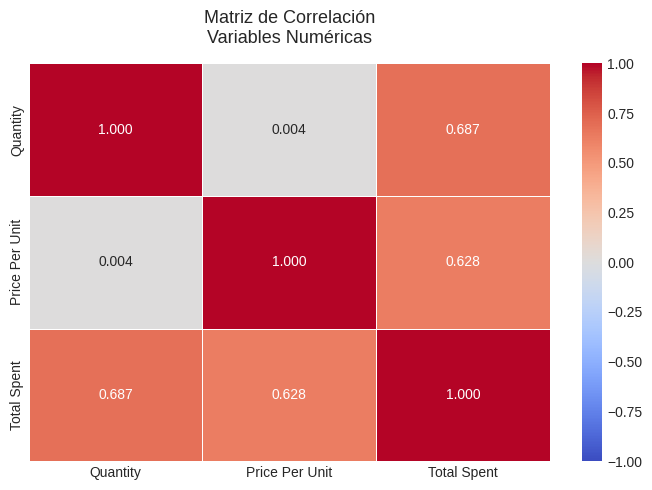

Gráfica guardada como heatmap_correlacion.png


In [166]:
# Matriz de Correlación

# Calculamos la correlación entre variables numéricas
correlacion = df_limpio[['Quantity', 'Price Per Unit', 'Total Spent']].corr()

print('=== MATRIZ DE CORRELACIÓN ===')
print(correlacion.round(3))
print()
print('Interpretación rápida:')
print(f'  Quantity ↔ Total Spent: {correlacion.loc["Quantity","Total Spent"]:.3f}')
print(f'  Price Per Unit ↔ Total Spent: {correlacion.loc["Price Per Unit","Total Spent"]:.3f}')

# Visualizar como heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    correlacion,
    annot=True,        # Mostrar el número dentro de cada celda
    fmt='.3f',         # Formato: 3 decimales
    cmap='coolwarm',   # Paleta de colores: azul (negativo) → rojo (positivo)
    vmin=-1, vmax=1,   # Escala fija de -1 a 1
    linewidths=0.5
)
plt.title('Matriz de Correlación\nVariables Numéricas', pad=15, fontsize=13)
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=120)
plt.show()
print('Gráfica guardada como heatmap_correlacion.png')

# *SECCIÓN 8: Visualización de Datos*

Contando una historia con gráficas
Las visualizaciones son el puente entre los números y las personas. Una buena gráfica le permite a alguien que NO sabe de datos entender un hallazgo importante en segundos.

Vamos a construir 8 gráficas que responden preguntas de negocio reales.

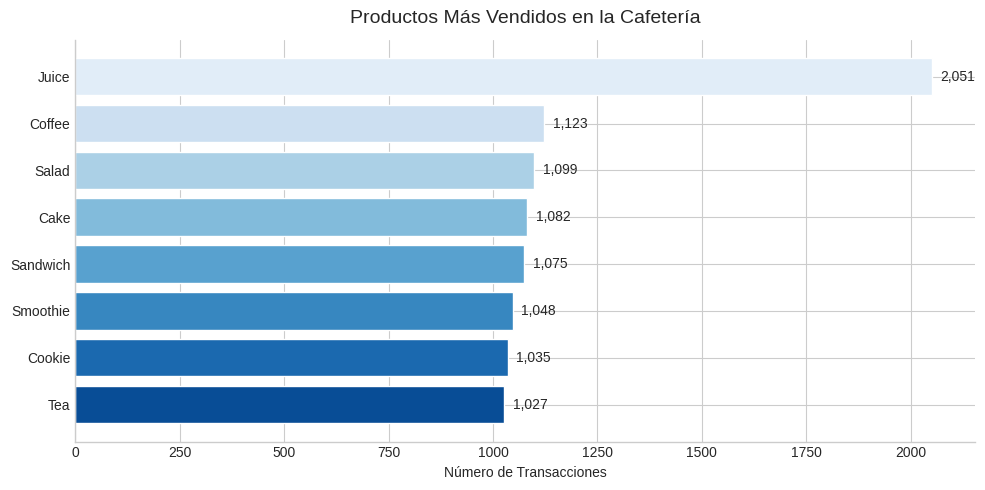

 Hallazgo: El producto más vendido es "Juice" con 2,051 ventas


In [167]:
# GRÁFICA 1: ¿Cuáles son los productos más vendidos?

# Contamos cuántas veces aparece cada producto

productos = df_limpio['Item'].value_counts().reset_index()
productos.columns = ['Producto', 'Ventas']

# Ordenamos de mayor a menor para que la barra más larga esté arriba
productos = productos.sort_values('Ventas', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

# barh = barra horizontal (más fácil de leer cuando hay muchas categorías)
bars = ax.barh(
    productos['Producto'],
    productos['Ventas'],
    color=sns.color_palette('Blues_r', len(productos)),
    edgecolor='white'
)

# Agregar etiquetas con el número de ventas al final de cada barra
for bar, val in zip(bars, productos['Ventas']):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_title('Productos Más Vendidos en la Cafetería', fontsize=14, pad=12)
ax.set_xlabel('Número de Transacciones')
ax.set_ylabel('')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('g1_productos.png', dpi=120)
plt.show()
print(f' Hallazgo: El producto más vendido es "{productos.iloc[-1]["Producto"]}" con {productos.iloc[-1]["Ventas"]:,} ventas')

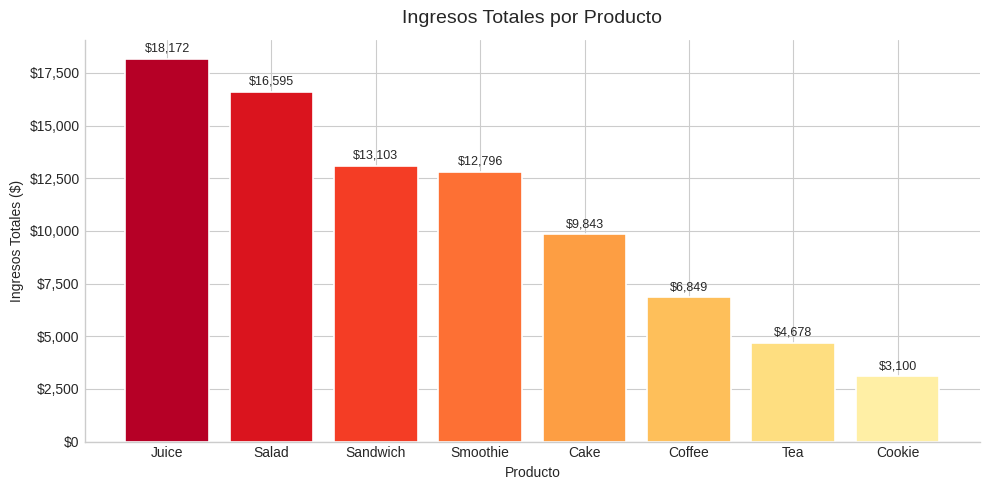

 Hallazgo: "Juice" genera los mayores ingresos: $18,171.50


In [168]:

# GRÁFICA 2: ¿Qué producto genera más ingresos totales?


import matplotlib.ticker as mticker

# .groupby() agrupa las filas por categoría y luego aplica una función
# Aquí: agrupamos por producto y SUMAMOS los ingresos de cada uno
ingresos_producto = (
    df_limpio.groupby('Item')['Total Spent']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
ingresos_producto.columns = ['Producto', 'Ingresos Totales']

fig, ax = plt.subplots(figsize=(10, 5))

# Paleta de colores del más alto al más bajo ingreso

colores = sns.color_palette('YlOrRd', len(ingresos_producto))[::-1]

bars = ax.bar(
    ingresos_producto['Producto'],
    ingresos_producto['Ingresos Totales'],
    color=colores,
    edgecolor='white',
    linewidth=1.2
)

# Etiquetas encima de cada barra con el total en dólares

for bar, val in zip(bars, ingresos_producto['Ingresos Totales']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 200,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Ingresos Totales por Producto', fontsize=14, pad=12)
ax.set_xlabel('Producto')
ax.set_ylabel('Ingresos Totales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('g2_ingresos_producto.png', dpi=120)
plt.show()

top = ingresos_producto.iloc[0]
print(f' Hallazgo: "{top["Producto"]}" genera los mayores ingresos: ${top["Ingresos Totales"]:,.2f}')

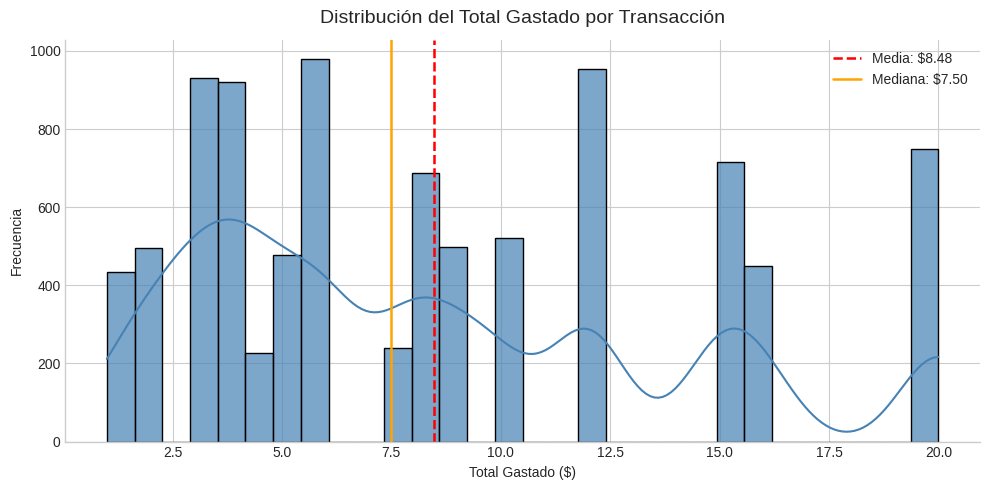

 Hallazgo: La mayoría de las transacciones están entre $4 y $12


In [169]:
# GRÁFICA 3: Distribución del Total Gastado por Transacción

# Un histograma muestra cómo se distribuyen los valores de una variable
# El eje X = rangos de valores, el eje Y = cuántas veces cae en ese rango
# La línea KDE = estimación de la curva de distribución (forma suavizada)

fig, ax = plt.subplots(figsize=(10, 5))

# kde=True agrega la curva de densidad sobre el histograma
sns.histplot(
    df_sin_outliers['Total Spent'],
    bins=30,
    kde=True,
    color='steelblue',
    alpha=0.7,
    ax=ax
)

# Líneas verticales para la media y la mediana
media = df_sin_outliers['Total Spent'].mean()
mediana = df_sin_outliers['Total Spent'].median()

ax.axvline(media, color='red', linestyle='--', linewidth=1.8, label=f'Media: ${media:.2f}')
ax.axvline(mediana, color='orange', linestyle='-', linewidth=1.8, label=f'Mediana: ${mediana:.2f}')

ax.set_title('Distribución del Total Gastado por Transacción', fontsize=14, pad=12)
ax.set_xlabel('Total Gastado ($)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('g3_distribucion.png', dpi=120)
plt.show()

print(f' Hallazgo: La mayoría de las transacciones están entre ${df_sin_outliers["Total Spent"].quantile(0.25):.0f} y ${df_sin_outliers["Total Spent"].quantile(0.75):.0f}')

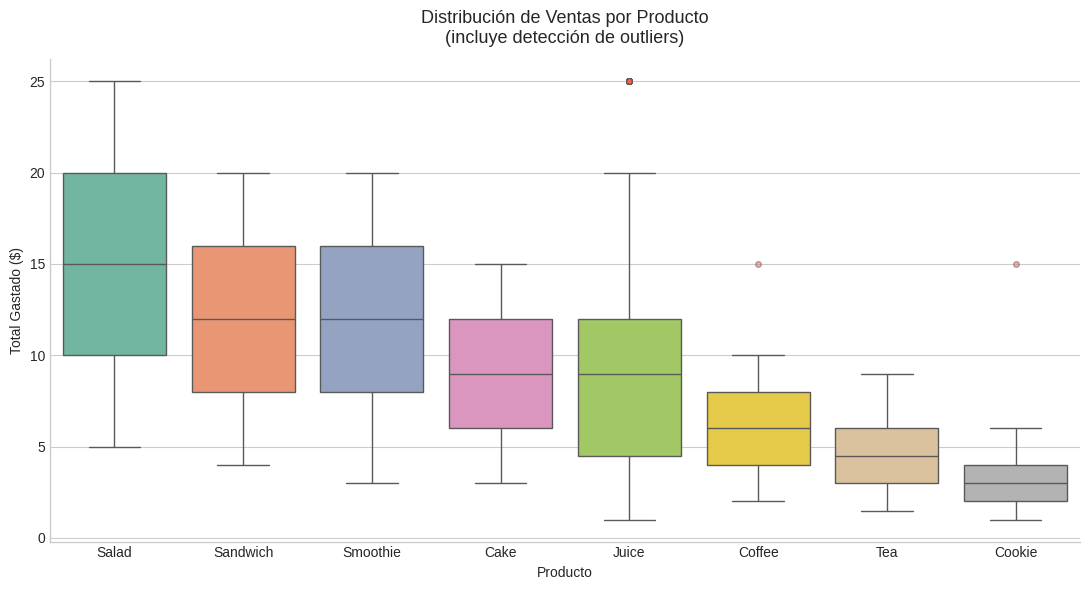

 Los puntos rojos fuera de los bigotes son outliers — transacciones inusualmente grandes o pequeñas


In [170]:
# GRÁFICA 4: Boxplot — Ventas por Producto (detección visual de outliers)

# Un BOXPLOT (diagrama de caja) muestra en una sola figura:
#   - La mediana (línea dentro de la caja)
#   - Q1 y Q3 (los bordes de la caja)
#   - IQR (el tamaño de la caja)
#   - Outliers (los puntos fuera de los bigotes)

fig, ax = plt.subplots(figsize=(11, 6))

# Ordenamos los productos por mediana de ventas (de mayor a menor)
orden_mediana = (
    df_limpio.groupby('Item')['Total Spent'].median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=df_limpio,
    x='Item',
    y='Total Spent',
    order=orden_mediana,
    palette='Set2',
    flierprops=dict(marker='o', markerfacecolor='tomato', markersize=4, alpha=0.5),
    ax=ax
)

ax.set_title('Distribución de Ventas por Producto\n(incluye detección de outliers)', fontsize=13, pad=12)
ax.set_xlabel('Producto')
ax.set_ylabel('Total Gastado ($)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('g4_boxplot_producto.png', dpi=120)
plt.show()

print(' Los puntos rojos fuera de los bigotes son outliers — transacciones inusualmente grandes o pequeñas')

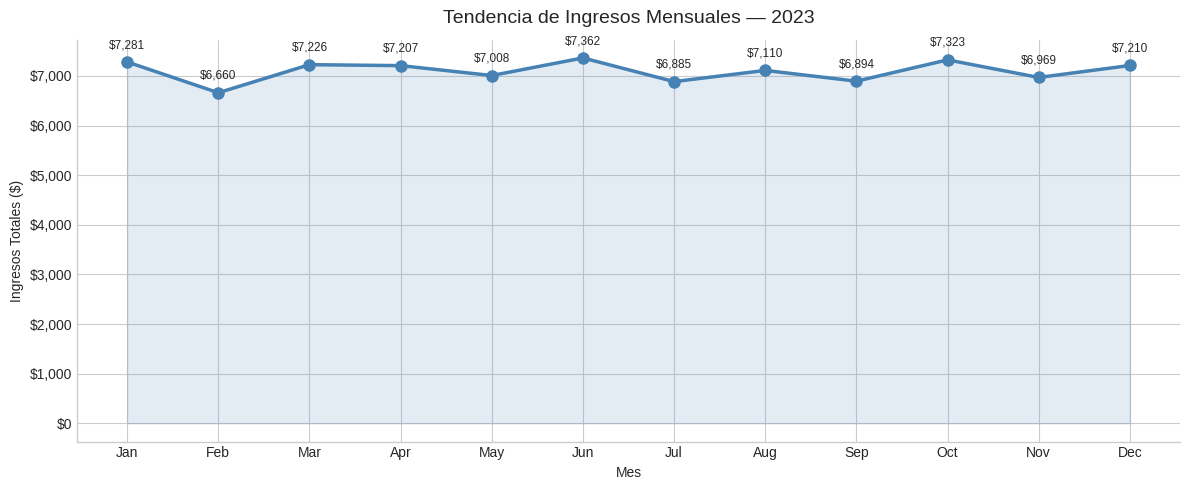

 Hallazgo: El mes de mayor ingreso fue Jun con $7,362.00


In [171]:
# GRÁFICA 5: Tendencia de Ventas Mensuales

# Agrupamos por mes y sumamos los ingresos de ese mes
ventas_mensuales = (
    df_limpio.groupby('Mes')['Total Spent']
    .sum()
    .reset_index()
)

# Agregamos nombres de mes para que sea más legible
import calendar
ventas_mensuales['Nombre_Mes'] = ventas_mensuales['Mes'].apply(
    lambda m: calendar.month_abbr[m]  # Ene, Feb, Mar...
)

fig, ax = plt.subplots(figsize=(12, 5))

# Línea de tendencia
ax.plot(
    ventas_mensuales['Nombre_Mes'],
    ventas_mensuales['Total Spent'],
    marker='o',        # Círculo en cada punto
    color='steelblue',
    linewidth=2.5,
    markersize=8
)

# Rellenar el área bajo la línea para efecto visual
ax.fill_between(
    ventas_mensuales['Nombre_Mes'],
    ventas_mensuales['Total Spent'],
    alpha=0.15,
    color='steelblue'
)

# Etiquetas de valor en cada punto
for _, row in ventas_mensuales.iterrows():
    ax.annotate(
        f'${row["Total Spent"]:,.0f}',
        (row['Nombre_Mes'], row['Total Spent']),
        textcoords='offset points', xytext=(0, 10),
        ha='center', fontsize=8.5
    )

ax.set_title('Tendencia de Ingresos Mensuales — 2023', fontsize=14, pad=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos Totales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('g5_tendencia_mensual.png', dpi=120)
plt.show()

mes_top = ventas_mensuales.loc[ventas_mensuales['Total Spent'].idxmax()]
print(f' Hallazgo: El mes de mayor ingreso fue {mes_top["Nombre_Mes"]} con ${mes_top["Total Spent"]:,.2f}')

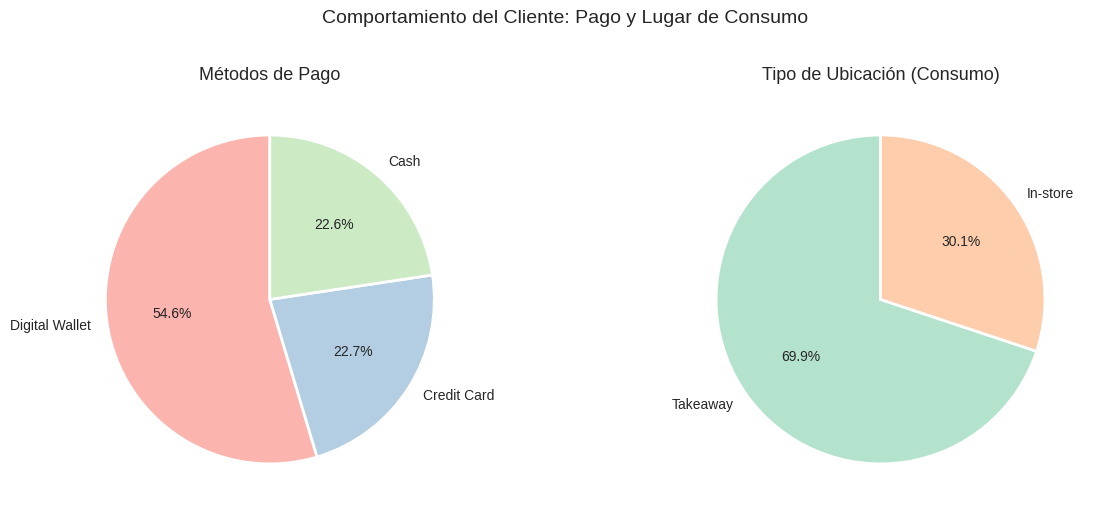

 Método de pago más usado: Digital Wallet (54.6%)
 Ubicación predominante: Takeaway (69.9%)


In [172]:
# GRÁFICA 6: Métodos de Pago y Ubicación (gráficas de pastel)

# Las gráficas de pastel funcionan bien cuando tenemos pocas categorías
# y queremos mostrar la proporción del todo

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Métodos de Pago ---
pagos_conteo = df_limpio['Payment Method'].value_counts()
ax1.pie(
    pagos_conteo.values,
    labels=pagos_conteo.index,
    autopct='%1.1f%%',    # Mostrar porcentaje con 1 decimal
    startangle=90,         # Empezar desde arriba
    colors=sns.color_palette('Pastel1', len(pagos_conteo)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax1.set_title('Métodos de Pago', fontsize=13, pad=10)

# --- Ubicación ---
ubicacion_conteo = df_limpio['Location'].value_counts()
ax2.pie(
    ubicacion_conteo.values,
    labels=ubicacion_conteo.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Pastel2', len(ubicacion_conteo)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax2.set_title('Tipo de Ubicación (Consumo)', fontsize=13, pad=10)

plt.suptitle('Comportamiento del Cliente: Pago y Lugar de Consumo',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('g6_pago_ubicacion.png', dpi=120, bbox_inches='tight')
plt.show()

print(f' Método de pago más usado: {pagos_conteo.idxmax()} ({pagos_conteo.max()/pagos_conteo.sum()*100:.1f}%)')
print(f' Ubicación predominante: {ubicacion_conteo.idxmax()} ({ubicacion_conteo.max()/ubicacion_conteo.sum()*100:.1f}%)')

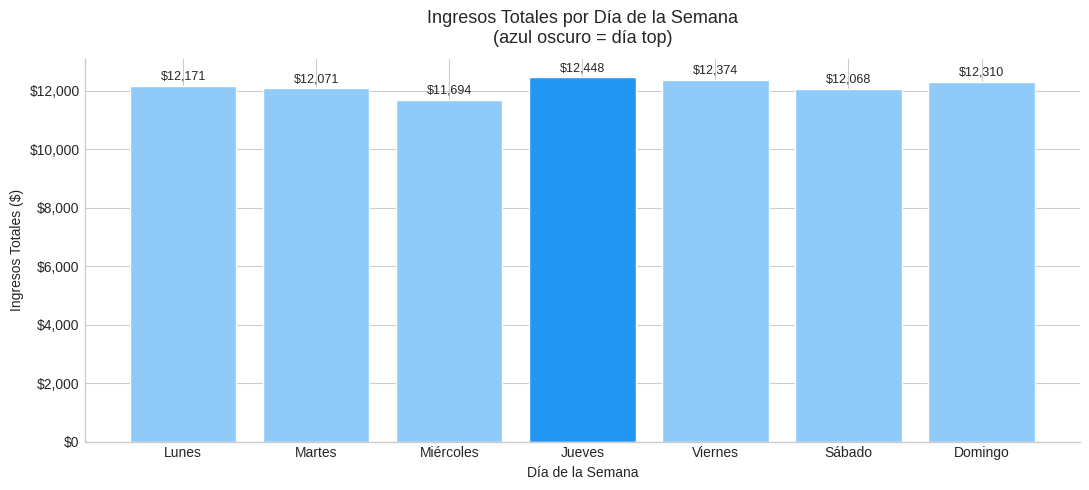

 Hallazgo: El día con más ventas es Jueves con $12,448.00


In [173]:
# GRÁFICA 7: Ventas por Día de la Semana

# ¿Qué días venden más?

# Definir el orden correcto de los días (de Lunes a Domingo)
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
nombres_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

ventas_dia = (
    df_limpio.groupby('Dia_Semana')['Total Spent']
    .sum()
    .reindex(orden_dias)  # Forzar el orden correcto
    .reset_index()
)
ventas_dia['Dia_ES'] = nombres_dias  # Agregar nombres en español

fig, ax = plt.subplots(figsize=(11, 5))

# Colorear más oscuro el día con más ventas

max_val = ventas_dia['Total Spent'].max()
colores = ['#2196F3' if v == max_val else '#90CAF9' for v in ventas_dia['Total Spent']]

bars = ax.bar(ventas_dia['Dia_ES'], ventas_dia['Total Spent'], color=colores, edgecolor='white')

for bar, val in zip(bars, ventas_dia['Total Spent']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 100,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Ingresos Totales por Día de la Semana\n(azul oscuro = día top)', fontsize=13, pad=12)
ax.set_xlabel('Día de la Semana')
ax.set_ylabel('Ingresos Totales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('g7_ventas_dia_semana.png', dpi=120)
plt.show()

dia_top = ventas_dia.loc[ventas_dia['Total Spent'].idxmax()]
print(f' Hallazgo: El día con más ventas es {dia_top["Dia_ES"]} con ${dia_top["Total Spent"]:,.2f}')

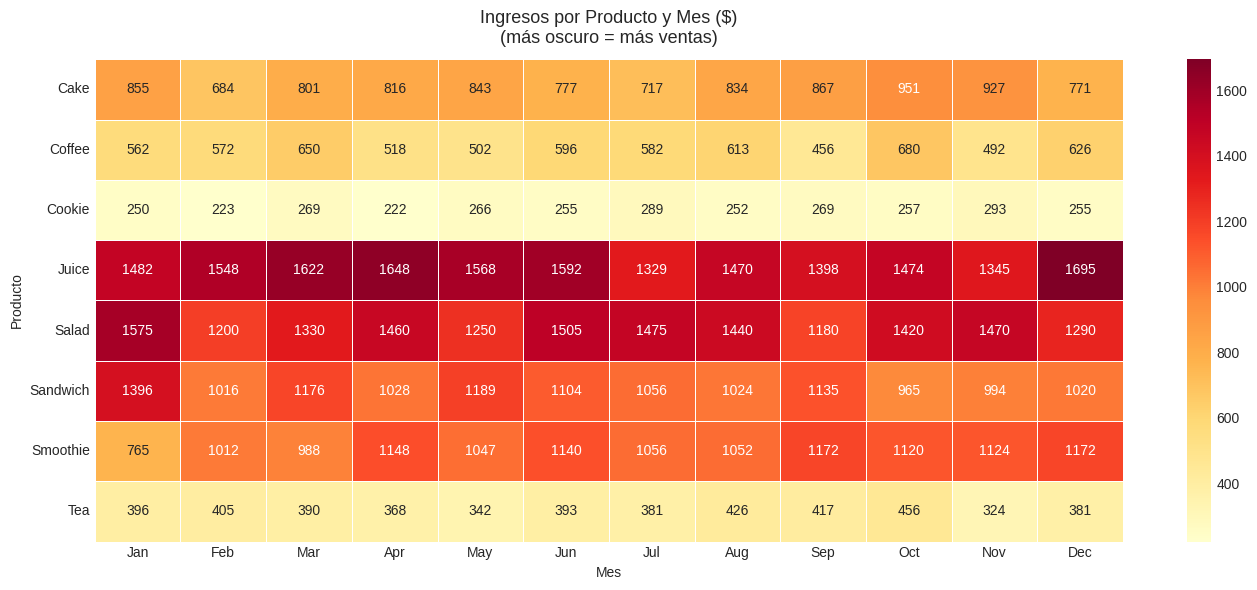

 Esta gráfica permite identificar combinaciones de producto-mes con mejor desempeño


In [174]:
# GRÁFICA 8: Heatmap — Ventas por Producto y Mes

# Esta gráfica combina dos variables categóricas en un mapa de calor
# Nos permite ver de un vistazo: ¿qué producto vendió más en qué mes?

# .pivot_table() crea una tabla cruzada (como una tabla dinámica de Excel)
import calendar
pivot = df_limpio.pivot_table(
    index='Item',
    columns='Mes',
    values='Total Spent',
    aggfunc='sum'
)

# Renombrar columnas con nombres de mes abreviados
pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    pivot,
    cmap='YlOrRd',       # Amarillo (bajo) → Rojo (alto)
    annot=True,           # Mostrar valores
    fmt='.0f',            # Sin decimales
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('Ingresos por Producto y Mes ($)\n(más oscuro = más ventas)', fontsize=13, pad=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Producto')
plt.tight_layout()
plt.savefig('g8_heatmap_producto_mes.png', dpi=120)
plt.show()

print(' Esta gráfica permite identificar combinaciones de producto-mes con mejor desempeño')

# **SECCIÓN 8: Análisis Estadístico — Regresión Lineal Simple**

Predecir el Total Gastado a partir de la Cantidad

La **regresión lineal simple** busca una relación lineal entre:

**Variable X** (independiente, la que conocemos):Quantity
**Variable Y** (dependiente, la que queremos predecir):Total Spent
La fórmula es: **Y = m·X + b**

- m= pendiente (cuánto sube Y cuando X sube 1 unidad)
- b= intercepto (el valor de Y cuando X = 0)

In [175]:
# Prepararemos los datos para la regresión

# Usaremos el dataset sin outliers para que el modelo sea más preciso
# Seleccionamos solo filas sin nulos en estas dos columnas

df_reg = df_sin_outliers[['Quantity', 'Total Spent']].dropna()

# X = variable independiente (necesita forma de matriz 2D: [[val1],[val2],...])
# .values.reshape(-1, 1) convierte la columna a matriz columna

X = df_reg[['Quantity']].values  # Ya es 2D con [['Quantity']]
y = df_reg['Total Spent'].values  # Vector 1D

print(f'Total de datos para regresión: {len(X):,}')
print(f'X (Quantity) — shape: {X.shape}')
print(f'y (Total Spent) — shape: {y.shape}')

Total de datos para regresión: 9,281
X (Quantity) — shape: (9281, 1)
y (Total Spent) — shape: (9281,)


** Para evaluar si el modelo realmente aprende (y no solo memoriza),
 dividimos los datos en dos grupos:
   - Entrenamiento (80%): el modelo aprende de estos datos
   - Prueba (20%): evaluamos qué tan bien predice en datos NUEVOS
-    random_state=42 es la "semilla" — Nos garantiza que la división sea siempre igual

In [176]:
# Dividir en datos de entrenamiento y prueba

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,     # 20% para prueba
    random_state=42
)

print(f'Datos de entrenamiento: {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Datos de prueba:        {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)')

Datos de entrenamiento: 7,424 (80%)
Datos de prueba:        1,857  (20%)


In [177]:
# Entrenamos el modelo de Regresión Lineal

from sklearn.linear_model import LinearRegression

# Creamos el modelo

modelo = LinearRegression()

# .fit() entrena el modelo — aquí es donde "aprende" la relación
# Le damos los datos de entrenamiento y él ajusta m y b

modelo.fit(X_train, y_train)

# Los parámetros aprendidos

m = modelo.coef_[0]      # Pendiente
b = modelo.intercept_    # Intercepto

print(' PARÁMETROS DEL MODELO ')
print(f'  Pendiente (m):    {m:.4f}')
print(f'  Intercepto (b):   {b:.4f}')
print()
print(f'  Fórmula aprendida: Total Spent = {m:.2f} × Quantity + {b:.2f}')
print()
print(f'  Interpretación: Por cada unidad adicional vendida, el total')
print(f'  aumenta en promedio ${m:.2f}')

 PARÁMETROS DEL MODELO 
  Pendiente (m):    2.6541
  Intercepto (b):   0.5586

  Fórmula aprendida: Total Spent = 2.65 × Quantity + 0.56

  Interpretación: Por cada unidad adicional vendida, el total
  aumenta en promedio $2.65


In [178]:
# Evaluaremos el rendimiento del modelo
# Predecimos sobre los datos de PRUEBA (que el modelo no vio antes)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modelo.predict(X_test)

#  Métricas de evaluación

# MAE (Mean Absolute Error) = Error Absoluto Medio
# Promedio de cuánto se equivoca el modelo (en las mismas unidades de Y = dólares)

mae = mean_absolute_error(y_test, y_pred)

# RMSE (Root Mean Squared Error) = Raíz del Error Cuadrático Medio
# Similar al MAE pero penaliza más los errores grandes

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Qué porcentaje de la variación de Y explica el modelo

# R² = 1.0 = perfecto | R² = 0.0 = no explica nada
# R² (R-cuadrada) = Coeficiente de Determinación

r2 = r2_score(y_test, y_pred)

print('=== MÉTRICAS DE EVALUACIÓN DEL MODELO ===')
print(f'  MAE  (Error promedio):          ${mae:.2f}')
print(f'  RMSE (Error con penalización):  ${rmse:.2f}')
print(f'  R²   (Calidad del ajuste):       {r2:.4f} ({r2*100:.1f}%)')
print()
print('Interpretación del R²:')
if r2 >= 0.7:
    print(f'   El modelo explica el {r2*100:.1f}% de la variación — buen ajuste')
elif r2 >= 0.4:
    print(f'    El modelo explica el {r2*100:.1f}% — ajuste moderado')
else:
    print(f'   El modelo explica solo el {r2*100:.1f}% — la relación lineal es débil')
    print('     Esto tiene sentido: el precio también depende del producto, no solo la cantidad')

=== MÉTRICAS DE EVALUACIÓN DEL MODELO ===
  MAE  (Error promedio):          $3.13
  RMSE (Error con penalización):  $3.95
  R²   (Calidad del ajuste):       0.4853 (48.5%)

Interpretación del R²:
    El modelo explica el 48.5% — ajuste moderado


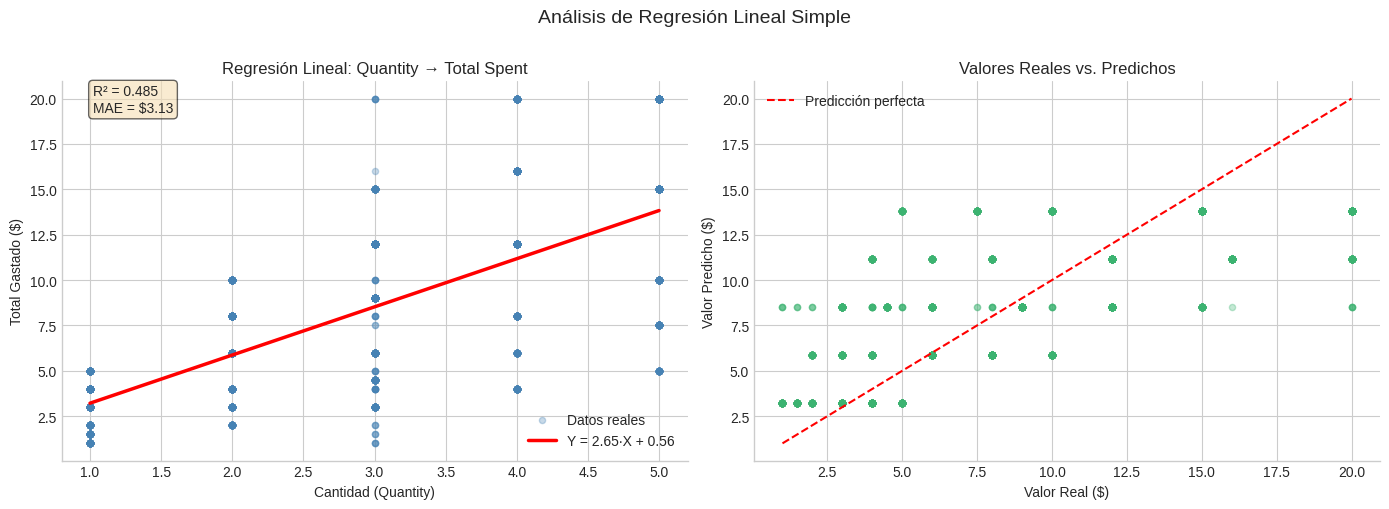

 La línea roja diagonal en la gráfica derecha es el "modelo perfecto"
   Mientras más cerca estén los puntos de esa línea, mejor predice el modelo


In [179]:
# Línea de Regresión Lineal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica izquierda: datos + línea de regresión

ax1 = axes[0]

# scatter: puntos de los datos reales

ax1.scatter(
    X_test, y_test,
    alpha=0.3, color='steelblue', s=20, label='Datos reales'
)

# Línea de regresión

x_linea = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
y_linea = modelo.predict(x_linea)
ax1.plot(x_linea, y_linea, color='red', linewidth=2.5,
         label=f'Y = {m:.2f}·X + {b:.2f}')

ax1.set_title('Regresión Lineal: Quantity → Total Spent', fontsize=12)
ax1.set_xlabel('Cantidad (Quantity)')
ax1.set_ylabel('Total Gastado ($)')
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)

# Añadir métricas al gráfico

ax1.text(0.05, 0.92, f'R² = {r2:.3f}\nMAE = ${mae:.2f}',
         transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

#  Gráfica derecha: valores reales vs predichos

ax2 = axes[1]

ax2.scatter(y_test, y_pred, alpha=0.3, color='mediumseagreen', s=20)

# Línea diagonal perfecta (real = predicho)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=1.5, label='Predicción perfecta')

ax2.set_title('Valores Reales vs. Predichos', fontsize=12)
ax2.set_xlabel('Valor Real ($)')
ax2.set_ylabel('Valor Predicho ($)')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Análisis de Regresión Lineal Simple', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('g9_regresion_lineal.png', dpi=120, bbox_inches='tight')
plt.show()

print(' La línea roja diagonal en la gráfica derecha es el "modelo perfecto"')
print('   Mientras más cerca estén los puntos de esa línea, mejor predice el modelo')

## Conclusiones y Hallazgos del Negocio

In [180]:
# Resumen ejecutivo con todos los hallazgos
# Recalculamos los valores para el resumen

producto_top_ventas = df_limpio['Item'].value_counts().idxmax()
producto_top_ingresos = df_limpio.groupby('Item')['Total Spent'].sum().idxmax()
ingreso_total = df_limpio['Total Spent'].sum()
ticket_promedio = df_limpio['Total Spent'].mean()
mes_mejor = df_limpio.groupby('Nombre_Mes')['Total Spent'].sum().idxmax()
pago_top = df_limpio['Payment Method'].value_counts().idxmax()
ubicacion_top = df_limpio['Location'].value_counts().idxmax()
dia_top_nombre = df_limpio.groupby('Dia_Semana')['Total Spent'].sum().idxmax()

print('='*60)
print('         RESUMEN EJECUTIVO — CAFÉ SALES 2023')
print('='*60)
print()
print(' VOLUMEN DE NEGOCIO')
print(f'   Total transacciones analizadas:  {len(df_limpio):>8,}')
print(f'   Ingresos totales del año:        ${ingreso_total:>10,.2f}')
print(f'   Ticket promedio por transacción: ${ticket_promedio:>10,.2f}')
print()
print(' PRODUCTO')
print(f'   Más vendido (# transacciones): {producto_top_ventas}')
print(f'   Mayor generador de ingresos:   {producto_top_ingresos}')
print()
print(' TEMPORALIDAD')
print(f'   Mes con más ingresos: {mes_mejor}')
print(f'   Día más productivo:   {dia_top_nombre}')
print()
print(' COMPORTAMIENTO DEL CLIENTE')
print(f'   Método de pago preferido: {pago_top}')
print(f'   Modalidad de consumo:     {ubicacion_top}')
print()
print(' MODELO PREDICTIVO')
print(f'   R² de regresión lineal: {r2:.3f} ({r2*100:.1f}% de varianza explicada)')
print(f'   Por cada unidad adicional vendida, el ingreso aumenta ${m:.2f}')
print()
print('='*60)
print()
print(' RECOMENDACIONES PARA EL NEGOCIO:')
print(f'   1. Fortalecer las promociones en {mes_mejor} (mes pico)')
print(f'   2. Incentivar el uso de {pago_top} (método preferido)')
print(f'   3. Considerar menú especial los {dia_top_nombre}s (día más productivo)')
print(f'   4. Explorar estrategias para aumentar el ticket promedio')
print(f'      (actualmente ${ticket_promedio:.2f} — ¿combos o tamaños grandes?)')

         RESUMEN EJECUTIVO — CAFÉ SALES 2023

 VOLUMEN DE NEGOCIO
   Total transacciones analizadas:     9,540
   Ingresos totales del año:        $ 85,136.00
   Ticket promedio por transacción: $      8.92

 PRODUCTO
   Más vendido (# transacciones): Juice
   Mayor generador de ingresos:   Juice

 TEMPORALIDAD
   Mes con más ingresos: June
   Día más productivo:   Thursday

 COMPORTAMIENTO DEL CLIENTE
   Método de pago preferido: Digital Wallet
   Modalidad de consumo:     Takeaway

 MODELO PREDICTIVO
   R² de regresión lineal: 0.485 (48.5% de varianza explicada)
   Por cada unidad adicional vendida, el ingreso aumenta $2.65


 RECOMENDACIONES PARA EL NEGOCIO:
   1. Fortalecer las promociones en June (mes pico)
   2. Incentivar el uso de Digital Wallet (método preferido)
   3. Considerar menú especial los Thursdays (día más productivo)
   4. Explorar estrategias para aumentar el ticket promedio
      (actualmente $8.92 — ¿combos o tamaños grandes?)


##  Dashboard visual Resumen
- Un dashboard es un panel con múltiples gráficas en una sola imagen
- Útil para presentar los hallazgos más importantes de forma compacta

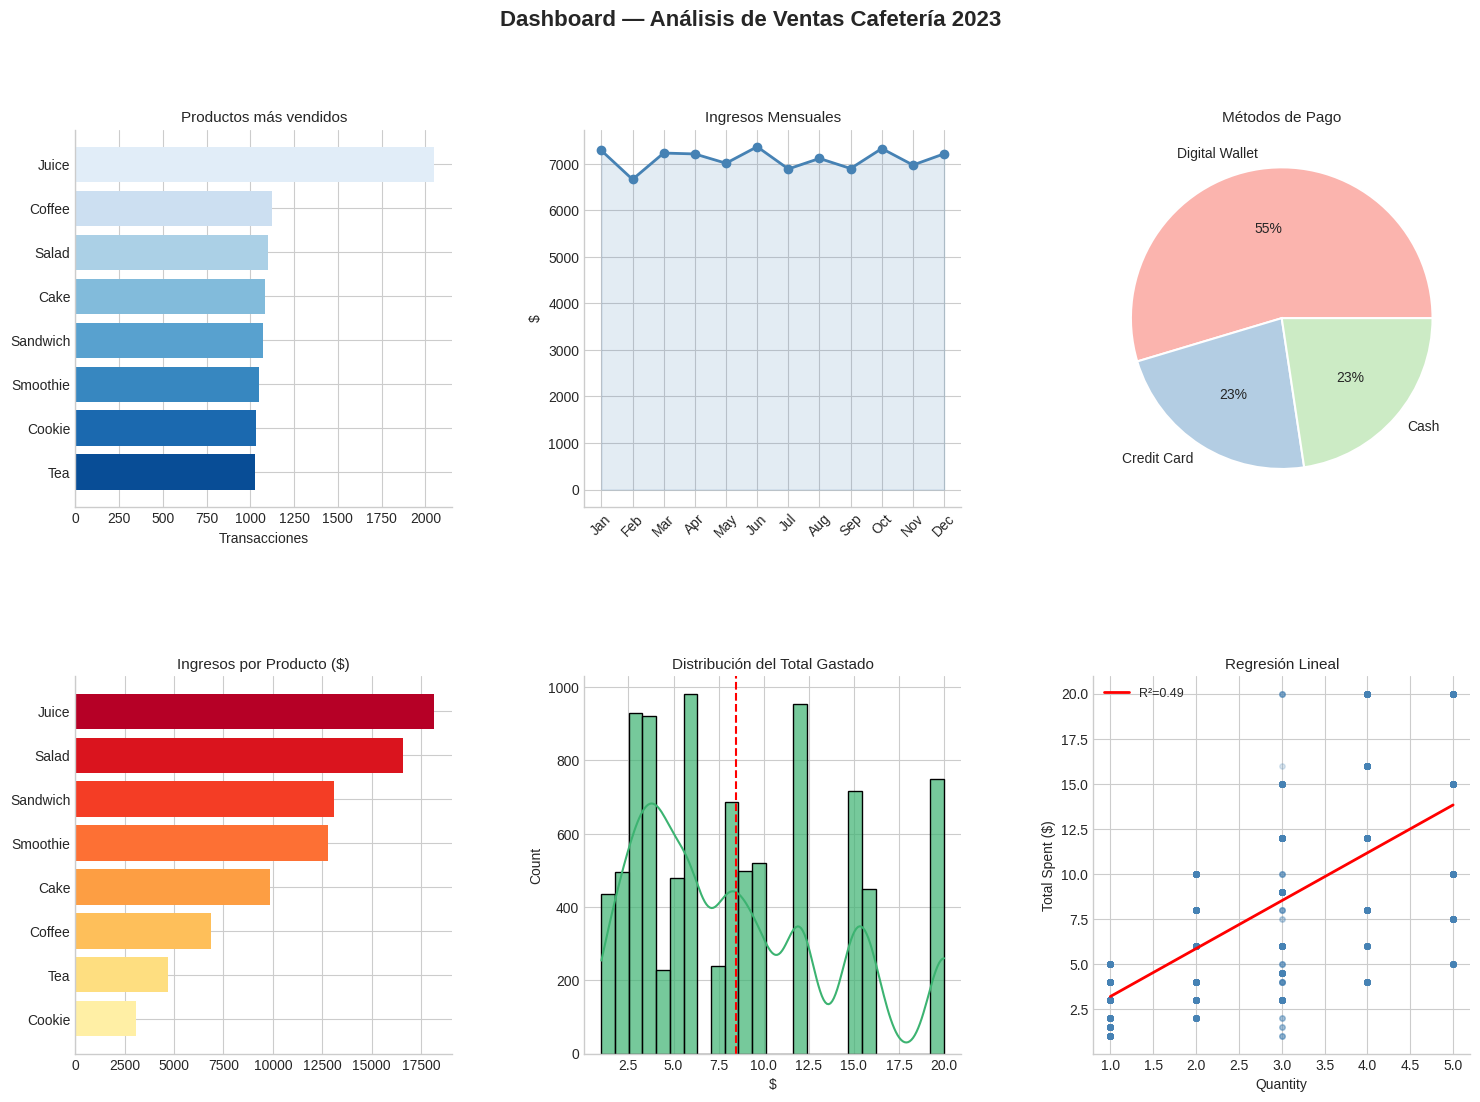

 Dashboard guardado como dashboard_final.png


In [181]:
import calendar

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Dashboard — Análisis de Ventas Cafetería 2023',
             fontsize=16, fontweight='bold', y=0.98)

# Definir cuadrícula de gráficas: 2 filas × 3 columnas

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

#  Panel 1: Productos más vendidos

ax1 = fig.add_subplot(gs[0, 0])
items_cnt = df_limpio['Item'].value_counts() # Changed from df to df_limpio
ax1.barh(items_cnt.index[::-1], items_cnt.values[::-1],
         color=sns.color_palette('Blues_r', len(items_cnt)))
ax1.set_title('Productos más vendidos', fontsize=11)
ax1.set_xlabel('Transacciones')
ax1.spines[['top', 'right']].set_visible(False)

#  Panel 2: Ventas mensuales
ax2 = fig.add_subplot(gs[0, 1])
vm = df_limpio.groupby('Mes')['Total Spent'].sum() # Changed from df to df_limpio
vm.index = [calendar.month_abbr[m] for m in vm.index]
ax2.plot(vm.index, vm.values, marker='o', color='steelblue', linewidth=2)
ax2.fill_between(range(len(vm)), vm.values, alpha=0.15, color='steelblue')
ax2.set_xticks(range(len(vm)))
ax2.set_xticklabels(vm.index, rotation=45)
ax2.set_title('Ingresos Mensuales', fontsize=11)
ax2.set_ylabel('$')
ax2.spines[['top', 'right']].set_visible(False)

# Panel 3: Método de pago

ax3 = fig.add_subplot(gs[0, 2])

pc = df_limpio['Payment Method'].value_counts() # Changed from df to df_limpio
ax3.pie(pc.values, labels=pc.index, autopct='%1.0f%%',
        colors=sns.color_palette('Pastel1', len(pc)),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax3.set_title('Métodos de Pago', fontsize=11)

#  Panel 4: Ingresos por producto

ax4 = fig.add_subplot(gs[1, 0])
ing_prod = df_limpio.groupby('Item')['Total Spent'].sum().sort_values(ascending=True) # Changed from df to df_limpio
ax4.barh(ing_prod.index, ing_prod.values,
         color=sns.color_palette('YlOrRd', len(ing_prod)))
ax4.set_title('Ingresos por Producto ($)', fontsize=11)
ax4.spines[['top', 'right']].set_visible(False)

#  Panel 5: Distribución Total Spent

ax5 = fig.add_subplot(gs[1, 1])
sns.histplot(df_sin_outliers['Total Spent'], bins=25, kde=True,
             color='mediumseagreen', alpha=0.7, ax=ax5)
ax5.axvline(df_sin_outliers['Total Spent'].mean(), color='red',
            linestyle='--', linewidth=1.5)
ax5.set_title('Distribución del Total Gastado', fontsize=11)
ax5.set_xlabel('$')
ax5.spines[['top', 'right']].set_visible(False)

#  Panel 6: Regresión

ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(X_test, y_test, alpha=0.2, color='steelblue', s=15)
ax6.plot(x_linea, y_linea, color='red', linewidth=2,
         label=f'R²={r2:.2f}')
ax6.set_title('Regresión Lineal', fontsize=11)
ax6.set_xlabel('Quantity')
ax6.set_ylabel('Total Spent ($)')
ax6.legend(fontsize=9)
ax6.spines[['top', 'right']].set_visible(False)

plt.savefig('dashboard_final.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Dashboard guardado como dashboard_final.png')